# N-MNIST 事件流檢視

兩種影像重建(繪圖邏輯都在 `data/viz/nmnist.py`):

- `accumulated_image`:從 t=0 累積到某時間點為止的全部事件(看到目前為止的完整輪廓)。
- 逐時間區段檢視:只看單一 `[k*bin, (k+1)*bin)` ms 區段內的事件,不累積前面。
  下面用 `ipywidgets` 的 slider / Play 即時切換,每次只重畫當下那一格
  (不是預先渲染好全部幀,也不是獨立 GUI 視窗)。

**參數的所有權**(規格書「data/ 資料前處理與視覺化架構規範」):`max_events`
(事件截斷長度)這種實驗參數在下面「參數」cell 明確設定,再傳進 `NMNISTDataset`。

跑法:`jax` conda 環境(`requirements.txt` 已含 jupyterlab / ipywidgets /
matplotlib)。repo 根 `pip install -e . --no-deps` 之後,`jupyter lab` 開這個檔案。
dataset 路徑由 `data.paths.DATASET_ROOT` 提供(從檔案位置推),不需要環境變數。

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from data.paths import DATASET_ROOT
from data.src.nmnist import CLASS_NAMES, NMNISTDataset
from data.viz.nmnist import (accumulated_image, binned_image, plot_time_histogram,
                             n_time_bins, diff_vmax)

## 參數

改這裡,不改函式庫。

In [12]:
# 資料集建構參數(會影響資料本身)
MAX_EVENTS = 10000   # 每個樣本對齊的事件數;超過截斷、不足 pad(規格書當前值) 所以要看完整的資料就設定大一點

# 抽樣參數
SEED = 0
WHICH = "train"     # "train" / "val" / "test"
SAMPLE_INDEX = 0    # 抽出來的第幾個樣本

# 純繪圖旋鈕(不影響資料)
BIN_MS = 8.0        # 逐區段檢視每格的時間寬度(ms)
HIST_BINS = 30

ds = NMNISTDataset(DATASET_ROOT, max_events=MAX_EVENTS)
split = ds.build_split(seed=SEED, n_samples=SAMPLE_INDEX + 1, which=WHICH)

i = SAMPLE_INDEX
n = int(split.n_real_events[i])
x = split.x[i][:n]
y = split.y[i][:n]
c = split.c[i][:n]
t = split.event_times[i][:n]
print(f"digit={CLASS_NAMES[int(split.labels[i])]}, n_real_events={n}, "
      f"t range=[{int(t.min())}, {int(t.max())}] ms")

digit=6, n_real_events=2532, t range=[3, 305] ms


## 累積影像(到某筆事件為止的完整輪廓)

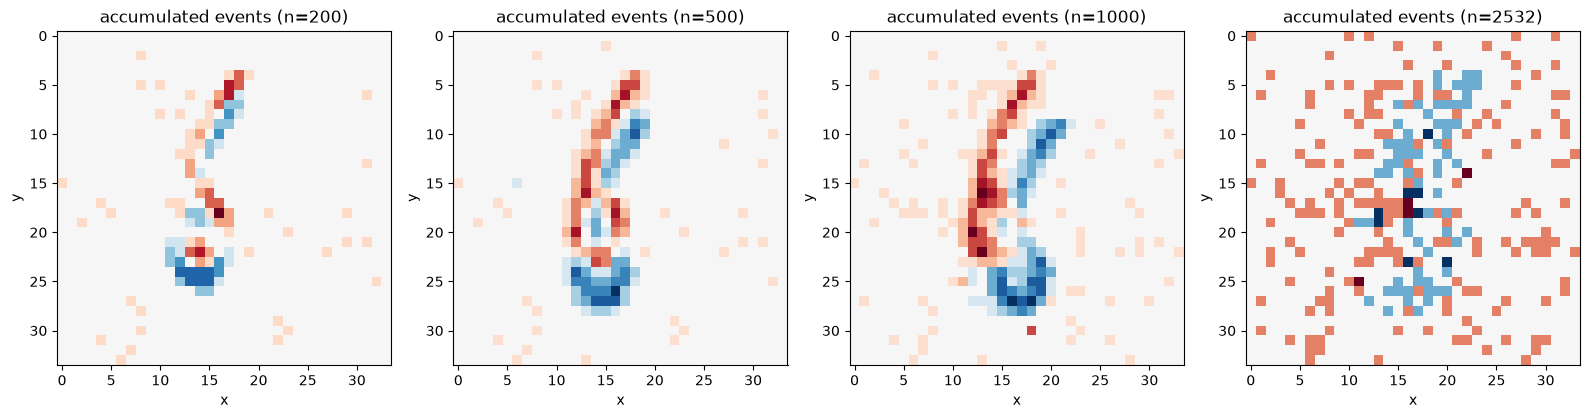

In [13]:
ups = [200, 500, 1000, None]
fig, axes = plt.subplots(1, len(ups), figsize=(4 * len(ups), 4))
for ax, up_to in zip(axes, ups):
    accumulated_image(x, y, c, ax, up_to=up_to)
fig.tight_layout()
plt.show()

## 逐時間區段檢視(slider 拖曳 / Play 播放,每格只顯示該區段的事件)

In [14]:
n_bins = n_time_bins(t, BIN_MS)
vmax = diff_vmax(x, y, c)   # 全段共用同一色階,不同幀顏色深淺才能比較

def show_bin(k):
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    binned_image(x, y, c, t, ax, k * BIN_MS, (k + 1) * BIN_MS, vmax=vmax)
    plt.show()

slider = widgets.IntSlider(min=0, max=n_bins - 1, step=1, value=0, description="bin")
play = widgets.Play(min=0, max=n_bins - 1, step=1, interval=200)
widgets.jslink((play, "value"), (slider, "value"))
out = widgets.interactive_output(show_bin, {"k": slider})
display(widgets.HBox([play, slider]), out)

Output()

## 事件時間分布(整體 vs OFF/ON)

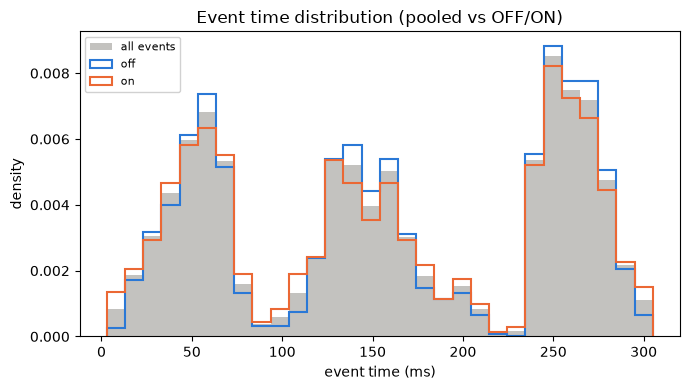

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_time_histogram(t, c, ax, bins=HIST_BINS)
fig.tight_layout()
plt.show()